In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model_cnn.train import build_model
from src.utility.config import DATASET_SPECS

RUN_ID = '20260708_140413_24210'  # run whose CSVs you want to analyse
CSV_DIR = PROJECT_ROOT / 'results' / RUN_ID / 'csv'

trace_df = pd.read_csv(CSV_DIR / 'layerwise_hessian_traces.csv')
print('trace rows:', len(trace_df))
print('layer sample:', trace_df['layer'].iloc[0])
trace_df.head()

trace rows: 486
layer sample: conv1.weight


,model,dataset,stage,layer,trace
0,cnn,IMAGENET100,FP32,conv1.weight,447.350716
1,cnn,IMAGENET100,FP32,conv2.weight,2221.976337
2,cnn,IMAGENET100,FP32,conv3.weight,4258.705583
3,cnn,IMAGENET100,FP32,conv4.weight,455.853906
4,cnn,IMAGENET100,FP32,fc1.weight,219.723940


In [2]:
def get_param_counts(model_name: str, dataset_name: str) -> dict:
    specs = DATASET_SPECS[dataset_name]
    model = build_model(
        num_classes=specs['num_classes'],
        model_name=model_name,
        channels=specs['channels'],
        image_size=specs['image_size'],
    )  # CPU is fine; we only read shapes
    return {
        name: param.numel()
        for name, param in model.named_parameters()
        if 'weight' in name and param.dim() >= 2
    }


rows = []
for model_name, dataset_name in (
    trace_df[['model', 'dataset']].drop_duplicates().itertuples(index=False)
):
    for layer, n in get_param_counts(model_name, dataset_name).items():
        rows.append({
            'model': model_name,
            'dataset': dataset_name,
            'layer': layer,
            'param_count': n,
        })
counts_df = pd.DataFrame(rows)
print('count rows:', len(counts_df))
counts_df.head()

count rows: 162


,model,dataset,layer,param_count
0,cnn,IMAGENET100,conv1.weight,864
1,cnn,IMAGENET100,conv2.weight,18432
2,cnn,IMAGENET100,conv3.weight,73728
3,cnn,IMAGENET100,conv4.weight,294912
4,cnn,IMAGENET100,fc1.weight,1048576


In [ ]:
merged = trace_df.merge(counts_df, on=['model', 'dataset', 'layer'], how='left')

# safety net: every trace row must have matched a parameter count
missing = merged['param_count'].isna().sum()
print(f'unmatched rows: {missing}')
if missing:
    print('  -> layer-name mismatch between CSV and named_parameters(); fix before trusting results')
    print(merged[merged['param_count'].isna()][['model', 'dataset', 'layer']].drop_duplicates())

merged['trace_per_param'] = merged['trace'] / merged['param_count']
merged.head()

unmatched rows: 0


,model,dataset,stage,layer,trace,param_count,trace_per_param
0,cnn,IMAGENET100,FP32,conv1.weight,447.350716,864,0.517767
1,cnn,IMAGENET100,FP32,conv2.weight,2221.976337,18432,0.120550
2,cnn,IMAGENET100,FP32,conv3.weight,4258.705583,73728,0.057762
3,cnn,IMAGENET100,FP32,conv4.weight,455.853906,294912,0.001546
4,cnn,IMAGENET100,FP32,fc1.weight,219.723940,1048576,0.000210


In [8]:
print(f"{'model_name':<22}{'stage':<6}{'raw Pearson':>14}{'raw Spearman':>15}"
      f"{'norm Pearson':>15}{'norm Spearman':>16}")
print('-' * 66)
for model_name in merged["model"].unique():
    for stage in ["FP32", "PTQ", "QAT"]:
      sub = merged[(merged["model"] == model_name) & (merged["stage"] == stage)]
      raw_p = sub['trace'].corr(sub['param_count'])
      raw_s = sub['trace'].corr(sub['param_count'], method='spearman')
      norm_p = sub['trace_per_param'].corr(sub['param_count'])
      norm_s = sub["trace_per_param"].corr(sub["param_count"], method="spearman")
      print(f'{model_name:<22}{stage:<6}{raw_p:>14.3f}{raw_s:>15.3f}{norm_p:>15.3f}{norm_s:>16.3f}')

model_name            stage    raw Pearson   raw Spearman   norm Pearson   norm Spearman
------------------------------------------------------------------
cnn                   FP32          -0.232          0.049         -0.289          -0.769
cnn                   PTQ           -0.329         -0.307         -0.235          -0.737
cnn                   QAT           -0.309         -0.286         -0.324          -0.843
resnet18_no_weights   FP32           0.300          0.337         -0.256          -0.757
resnet18_no_weights   PTQ           -0.152         -0.063         -0.130          -0.761
resnet18_no_weights   QAT           -0.139          0.001         -0.135          -0.799
resnet50_no_weights   FP32           0.433          0.441         -0.145          -0.547
resnet50_no_weights   PTQ           -0.061          0.133         -0.101          -0.657
resnet50_no_weights   QAT           -0.036          0.364         -0.088          -0.706


saved trace_vs_paramcount.png


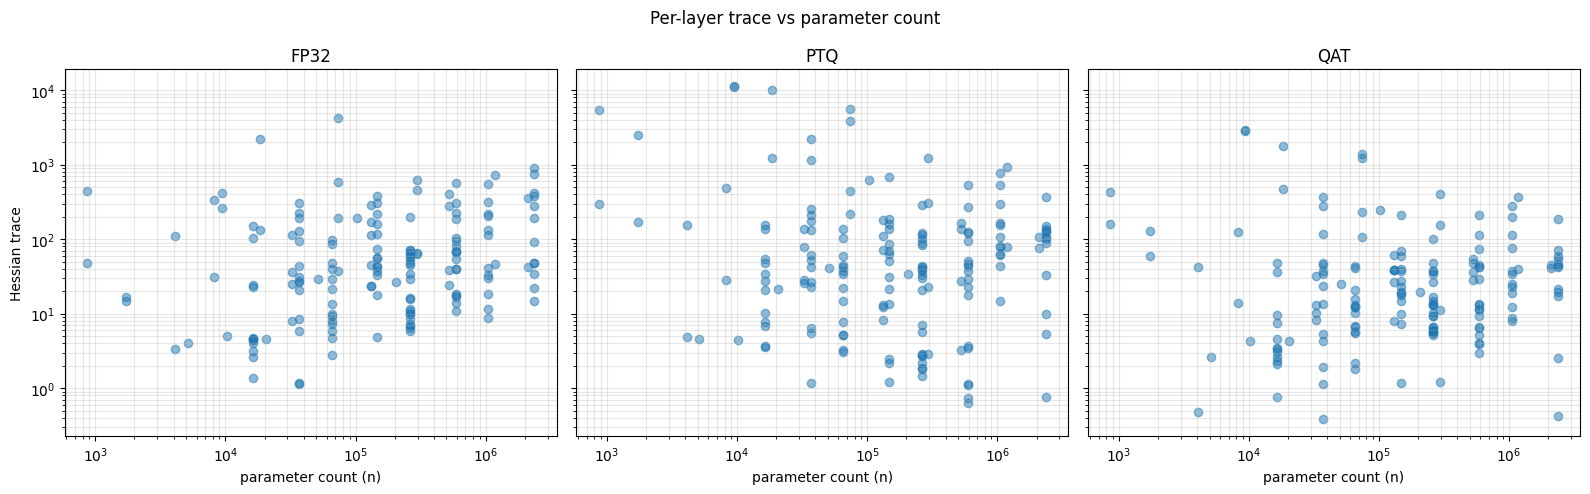

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, stage in zip(axes, ['FP32', 'PTQ', 'QAT']):
    sub = merged[merged['stage'] == stage]
    ax.scatter(sub['param_count'], sub['trace'], alpha=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('parameter count (n)')
    ax.set_title(stage)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('Hessian trace')
fig.suptitle('Per-layer trace vs parameter count')
fig.tight_layout()
fig.savefig('trace_vs_paramcount.png', dpi=150)
print('saved trace_vs_paramcount.png')

In [9]:
import numpy as np
from scipy.stats import linregress

for model_name in merged["model"].unique():
    for stage in ["FP32", "PTQ", "QAT"]:
        sub = merged[(merged["model"] == model_name) & (merged["stage"] == stage)].copy()
        
        # Filter non-positive traces to safely apply log
        sub = sub[sub["trace"] > 0]
        
        # Skip if not enough data points for regression
        if len(sub) < 2:
            continue
            
        x = np.log(sub["param_count"])
        y = np.log(sub["trace"])
        
        # Calculate linear regression
        res = linregress(x, y)
        alpha = res.slope
        r_squared = res.rvalue ** 2
        
        print(f"{model_name} | {stage:<4} -> alpha: {alpha:>6.3f} | R^2: {r_squared:>5.3f}")

cnn | FP32 -> alpha: -0.024 | R^2: 0.001
cnn | PTQ  -> alpha: -0.432 | R^2: 0.134
cnn | QAT  -> alpha: -0.341 | R^2: 0.116
resnet18_no_weights | FP32 -> alpha:  0.223 | R^2: 0.104
resnet18_no_weights | PTQ  -> alpha: -0.173 | R^2: 0.031
resnet18_no_weights | QAT  -> alpha: -0.112 | R^2: 0.017
resnet50_no_weights | FP32 -> alpha:  0.406 | R^2: 0.203
resnet50_no_weights | PTQ  -> alpha:  0.018 | R^2: 0.000
resnet50_no_weights | QAT  -> alpha:  0.252 | R^2: 0.093


In [10]:
def get_layer_depths(model_name, dataset_name):
    specs = DATASET_SPECS[dataset_name]
    model = build_model(
        num_classes=specs["num_classes"],
        model_name=model_name,
        channels=specs["channels"],
        image_size=specs["image_size"],
    )
    weight_layers = [
        name for name, p in model.named_parameters()
        if "weight" in name and p.dim() >= 2
    ]
    n = len(weight_layers)
    
    depth_mapping = {}
    for index, name in enumerate(weight_layers):
        # Prevent division by zero if only one layer exists
        depth_fraction = index / (n - 1) if n > 1 else 0.0
        depth_mapping[name] = (index, depth_fraction)
        
    return depth_mapping

In [11]:
rows = []
for model_name, dataset_name in (
    trace_df[["model", "dataset"]].drop_duplicates().itertuples(index=False)
):
    for layer, (idx, frac) in get_layer_depths(model_name, dataset_name).items():
        rows.append({
            "model": model_name,
            "dataset": dataset_name,
            "layer": layer,
            "depth_index": idx,
            "depth_fraction": frac,
        })
depth_df = pd.DataFrame(rows)

merged_depth = trace_df.merge(depth_df, on=["model", "dataset", "layer"], how="left")
missing = merged_depth["depth_index"].isna().sum()
print(f"unmatched rows: {missing}")

unmatched rows: 0


saved trace_vs_depth.png


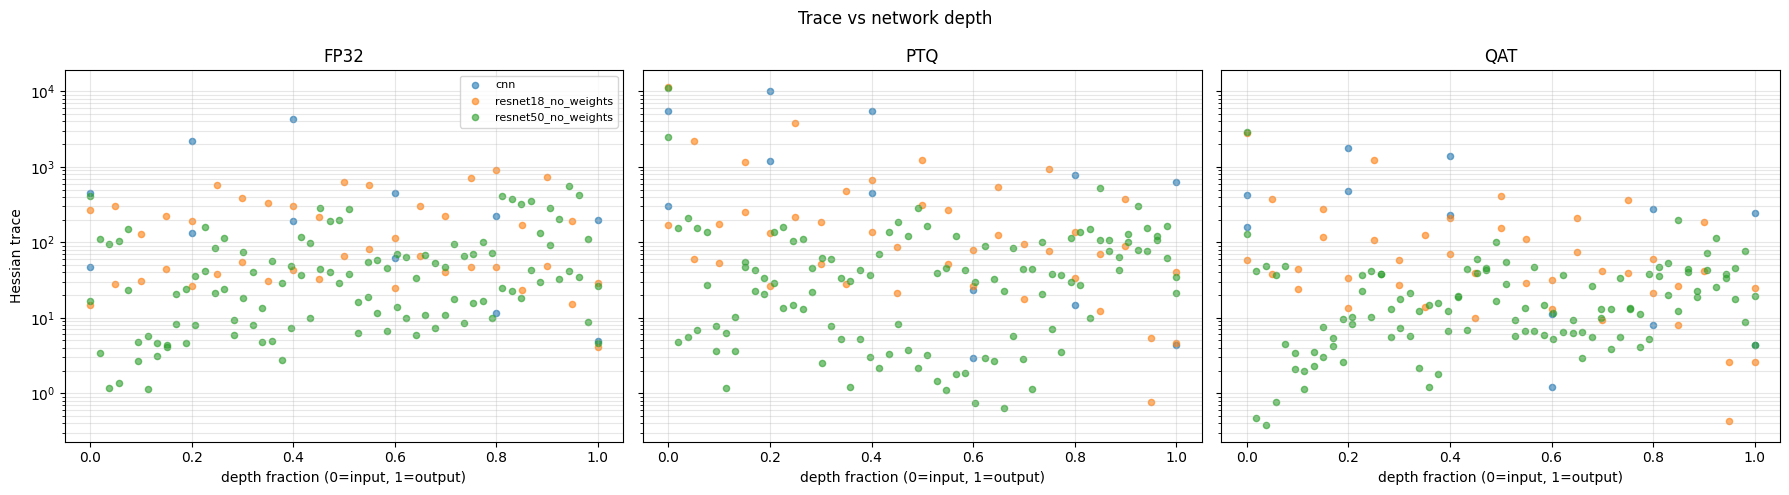

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, stage in zip(axes, ["FP32", "PTQ", "QAT"]):
    sub = merged_depth[merged_depth["stage"] == stage]
    for model_name in sub["model"].unique():
        m = sub[sub["model"] == model_name]
        ax.scatter(m["depth_fraction"], m["trace"], alpha=0.6, label=model_name, s=20)
    ax.set_yscale("log")
    ax.set_xlabel("depth fraction (0=input, 1=output)")
    ax.set_title(stage)
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel("Hessian trace")
axes[0].legend(fontsize=8)
fig.suptitle("Trace vs network depth")
fig.tight_layout()
fig.savefig("trace_vs_depth.png", dpi=150)
print("saved trace_vs_depth.png")

In [13]:
for model_name in merged_depth["model"].unique():
    for stage in ["FP32", "PTQ", "QAT"]:
        sub = merged_depth[
            (merged_depth["model"] == model_name) & (merged_depth["stage"] == stage)
        ]
        first = sub[sub["depth_index"] == 0]["trace"]
        rest = sub[sub["depth_index"] > 0]["trace"]
        
        # Extract scalar value for the first layer and median for the rest
        first_val = first.values[0]
        rest_median = rest.median()
        
        # Calculate ratio
        ratio = first_val / rest_median
        
        print(f"{model_name:<10} | {stage:<4} -> First layer: {first_val:>10.2f} | Median rest: {rest_median:>10.2f} | Ratio: {ratio:>6.2f}x")

cnn        | FP32 -> First layer:     447.35 | Median rest:     191.97 | Ratio:   2.33x
cnn        | PTQ  -> First layer:    5425.42 | Median rest:     536.67 | Ratio:  10.11x
cnn        | QAT  -> First layer:     429.06 | Median rest:     240.69 | Ratio:   1.78x
resnet18_no_weights | FP32 -> First layer:     265.05 | Median rest:      74.17 | Ratio:   3.57x
resnet18_no_weights | PTQ  -> First layer:   11349.63 | Median rest:      92.09 | Ratio: 123.25x
resnet18_no_weights | QAT  -> First layer:    2787.77 | Median rest:      40.80 | Ratio:  68.33x
resnet50_no_weights | FP32 -> First layer:     414.71 | Median rest:      29.45 | Ratio:  14.08x
resnet50_no_weights | PTQ  -> First layer:   10955.37 | Median rest:      34.26 | Ratio: 319.81x
resnet50_no_weights | QAT  -> First layer:    2923.87 | Median rest:      13.04 | Ratio: 224.19x


In [14]:
# load the sqnr CSV (adjust filename to whatever you saved it as)
sqnr_df = pd.read_csv(CSV_DIR / "layerwise_quant_error.csv")
print("sqnr rows:", len(sqnr_df))
print("stages present:", sqnr_df["stage"].unique())

# merge onto the trace data; inner join drops FP32 automatically
# (SQNR only exists for PTQ/QAT), which is what we want
merged_sqnr = trace_df.merge(
    sqnr_df, on=["model", "dataset", "stage", "layer"], how="inner"
)
print("merged rows:", len(merged_sqnr))
print("stages after merge:", merged_sqnr["stage"].unique())

sqnr rows: 324
stages present: <StringArray>
['PTQ', 'QAT']
Length: 2, dtype: str
merged rows: 324
stages after merge: <StringArray>
['PTQ', 'QAT']
Length: 2, dtype: str


In [15]:
for stage in ["PTQ", "QAT"]:
    sub = merged_sqnr[merged_sqnr["stage"] == stage]
    p = sub["sqnr"].corr(sub["trace"])
    s = sub["sqnr"].corr(sub["trace"], method="spearman")
    print(f"{stage}: Pearson={p:.3f}  Spearman={s:.3f}  (n={len(sub)})")

PTQ: Pearson=0.016  Spearman=0.020  (n=162)
QAT: Pearson=0.021  Spearman=0.079  (n=162)


saved


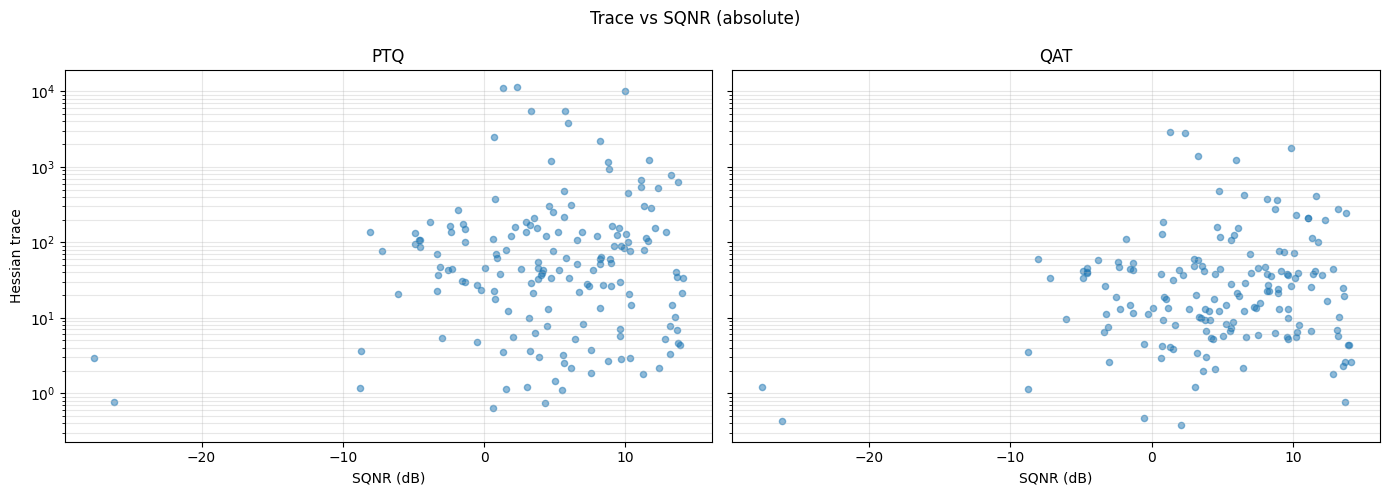

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, stage in zip(axes, ["PTQ", "QAT"]):
    sub = merged_sqnr[merged_sqnr["stage"] == stage]
    ax.scatter(sub["sqnr"], sub["trace"], alpha=0.5, s=20)
    ax.set_yscale("log")
    ax.set_xlabel("SQNR (dB)")
    ax.set_title(stage)
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel("Hessian trace")
fig.suptitle("Trace vs SQNR (absolute)")
fig.tight_layout()
fig.savefig("trace_vs_sqnr.png", dpi=150)
print("saved")

In [17]:
# pivot trace to wide: one row per (model, dataset, layer), stages as columns
trace_wide = trace_df.pivot_table(
    index=["model", "dataset", "layer"],
    columns="stage",
    values="trace",
).reset_index()
print(trace_wide.columns.tolist())
print("rows:", len(trace_wide))
trace_wide.head()

['model', 'dataset', 'layer', 'FP32', 'PTQ', 'QAT']
rows: 162


stage,model,dataset,layer,FP32,PTQ,QAT
0,cnn,CIFAR10,conv1.weight,47.448445,299.176424,158.834105
1,cnn,CIFAR10,conv2.weight,131.713808,1211.454604,477.250365
2,cnn,CIFAR10,conv3.weight,189.485810,445.036746,233.326513
3,cnn,CIFAR10,conv4.weight,62.544500,23.059589,11.248421
4,cnn,CIFAR10,fc1.weight,11.635193,14.967489,8.025615


In [18]:
import numpy as np

# guard: both traces must be positive to take the log-ratio
trace_wide = trace_wide[(trace_wide["FP32"] > 0) & (trace_wide["PTQ"] > 0)].copy()
trace_wide["log_ratio_ptq"] = np.log(trace_wide["PTQ"] / trace_wide["FP32"])

# attach the PTQ-stage SQNR for each layer
ptq_sqnr = sqnr_df[sqnr_df["stage"] == "PTQ"][["model", "dataset", "layer", "sqnr"]]
delta_ptq = trace_wide.merge(ptq_sqnr, on=["model", "dataset", "layer"], how="inner")
print("rows:", len(delta_ptq))

rows: 162


In [19]:
p = delta_ptq["sqnr"].corr(delta_ptq["log_ratio_ptq"])
s = delta_ptq["sqnr"].corr(delta_ptq["log_ratio_ptq"], method="spearman")
print(f"PTQ log-ratio vs SQNR: Pearson={p:.3f}  Spearman={s:.3f}  (n={len(delta_ptq)})")

PTQ log-ratio vs SQNR: Pearson=0.408  Spearman=0.375  (n=162)


saved


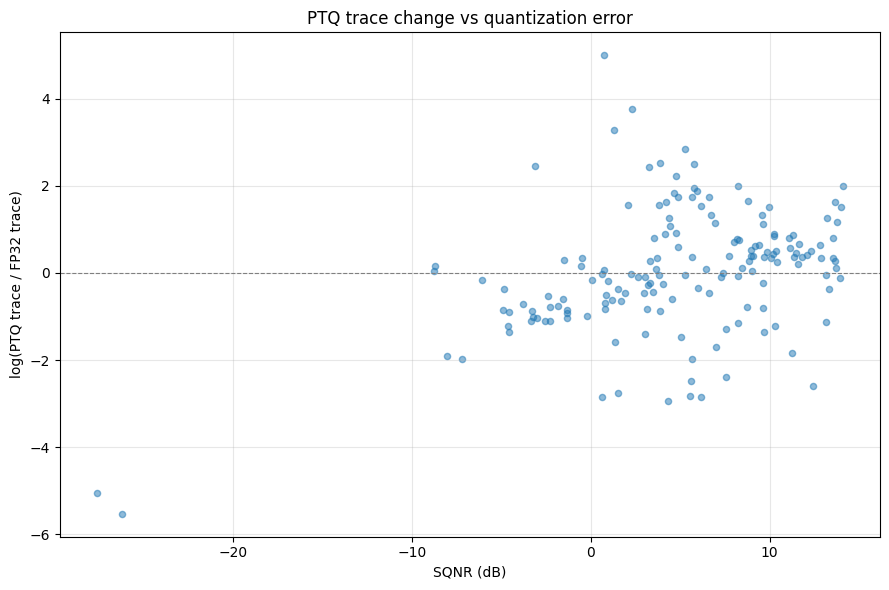

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(delta_ptq["sqnr"], delta_ptq["log_ratio_ptq"], alpha=0.5, s=20)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)  # trace unchanged
ax.set_xlabel("SQNR (dB)")
ax.set_ylabel("log(PTQ trace / FP32 trace)")
ax.set_title("PTQ trace change vs quantization error")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("logratio_vs_sqnr.png", dpi=150)
print("saved")

In [21]:
main = delta_ptq[delta_ptq["sqnr"] > -15]  # drop the two collapse outliers
p = main["sqnr"].corr(main["log_ratio_ptq"])
s = main["sqnr"].corr(main["log_ratio_ptq"], method="spearman")
print(f"excluding collapse outliers: Pearson={p:.3f}  Spearman={s:.3f}  (n={len(main)})")

excluding collapse outliers: Pearson=0.239  Spearman=0.351  (n=160)


In [22]:
EARLY_INDICES = [0, 1, 2, 3]
DEEP_CUTOFF = 4  # Layers at or after this index form the baseline median

for model_name in merged_depth["model"].unique():
    for stage in ["FP32", "PTQ", "QAT"]:  
        sub = merged_depth[
            (merged_depth["model"] == model_name) & (merged_depth["stage"] == stage)
        ]
        
        baseline = sub[sub["depth_index"] >= DEEP_CUTOFF]["trace"].median()
        
        ratios = []
        for idx in EARLY_INDICES:
            layer_trace = sub[sub["depth_index"] == idx]["trace"]
            r = (layer_trace.values[0] / baseline) if len(layer_trace) > 0 else float("nan")
            ratios.append(r)
            
        ratio_str = "  ".join(f"i{idx}:{r:6.2f}x" for idx, r in zip(EARLY_INDICES, ratios))
        print(f"{model_name:<22} | {stage:<5} | {ratio_str}")

cnn                    | FP32  | i0:  4.34x  i1: 21.56x  i2: 41.33x  i3:  4.42x
cnn                    | PTQ   | i0: 16.87x  i1: 31.39x  i2: 17.28x  i3:  0.01x
cnn                    | QAT   | i0:  3.35x  i1: 13.88x  i2: 10.95x  i3:  0.01x
resnet18_no_weights    | FP32  | i0:  3.57x  i1:  4.06x  i2:  1.75x  i3:  3.01x
resnet18_no_weights    | PTQ   | i0:129.04x  i1: 25.31x  i2:  1.98x  i3: 13.32x
resnet18_no_weights    | QAT   | i0: 70.33x  i1:  9.41x  i2:  1.13x  i3:  7.07x
resnet50_no_weights    | FP32  | i0: 14.08x  i1:  3.78x  i2:  3.23x  i3:  3.53x
resnet50_no_weights    | PTQ   | i0:319.81x  i1:  4.56x  i2:  6.15x  i3:  4.56x
resnet50_no_weights    | QAT   | i0:224.19x  i1:  3.23x  i2:  3.69x  i3:  2.81x
